Import Libraries:

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

Processed data Load:

In [2]:
X_test = pd.read_csv('../data/processed_data/X_test.csv')
y_test = pd.read_csv('../data/processed_data/y_test.csv').squeeze()

Load Best Model: 

In [3]:
model = joblib.load("../models/best_model.pkl")

Prediction:

In [4]:
y_pred = model.predict(X_test)

y_pred_prob = model.predict_proba(X_test)[:,1]

In [5]:
metrics_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC'],
    'Score': [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_pred_prob)
    ]
}


metrics_df = pd.DataFrame(metrics_data)

metrics_df['Score'] = metrics_df['Score'].round(4)

metrics_df

,Metric,Score
0,Accuracy,0.8062
1,Precision,0.6593
2,Recall,0.5588
3,F1 Score,0.6049
4,ROC-AUC,0.8422


Classification Report:

In [6]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



Confusion Matrix:

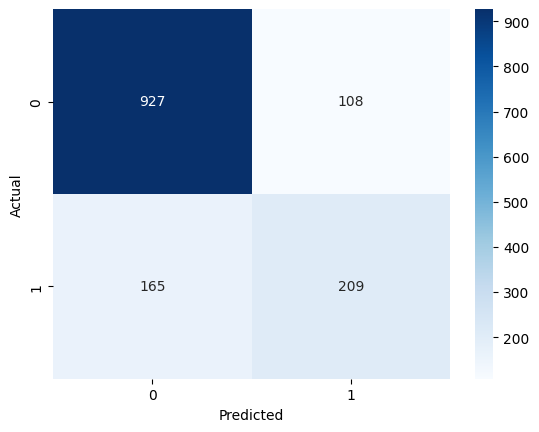

In [8]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

The model demonstrates strong predictive performance by correctly identifying 927 non-churn (True Negatives) and 209 churn (True Positives) instances. It misclassified 165 actual churn cases as non-churn (False Negatives) and 108 non-churn cases as churn (False Positives). Overall, it maintains high accuracy on the majority class while effectively capturing a significant portion of churners

ROC Curve:

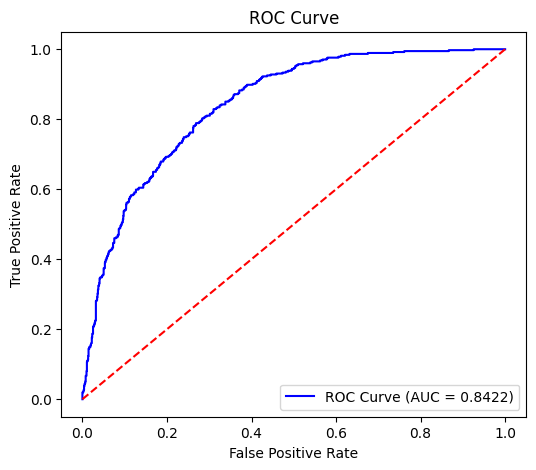

In [12]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
auc_score = roc_auc_score(y_test, y_pred_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--') # Random Line

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

The model achieves an AUC (Area Under the Curve) score of 0.8422, indicating strong overall capability in distinguishing between churning and non-churning customers.The blue ROC curve bows significantly toward the top-left corner, well above the random baseline (red dashed line). This demonstrates a high True Positive Rate while maintaining a low False Positive Rate across various classification thresholds.

Logistic Regression Coefficients:

In [13]:
feature_names = X_test.columns
coefficients = model.coef_[0]

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='Abs_Coefficient', ascending=False).reset_index(drop=True)

coef_df.head(10)

,Feature,Coefficient,Abs_Coefficient
0,Contract_Two year,-1.328243,1.328243
1,tenure,-1.249330,1.249330
2,InternetService_Fiber optic,1.193660,1.193660
3,Contract_One year,-0.685633,0.685633
4,TotalCharges,0.519893,0.519893
5,PhoneService,-0.500163,0.500163
6,MonthlyCharges,-0.481375,0.481375
7,StreamingTV_Yes,0.381099,0.381099
8,PaymentMethod_Electronic check,0.380941,0.380941
9,StreamingMovies_Yes,0.380234,0.380234


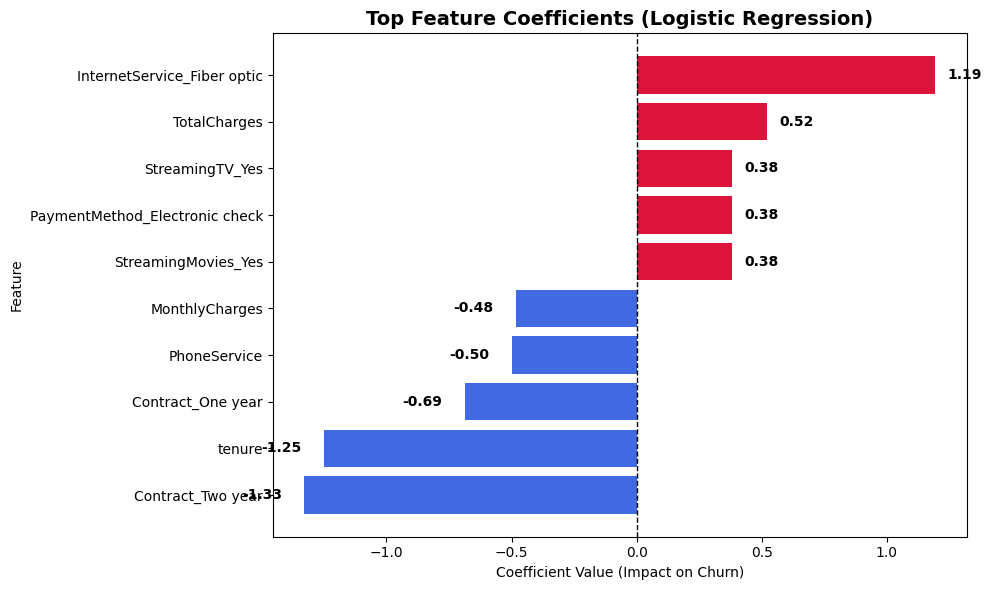

In [15]:
top_coef = coef_df.head(10).sort_values(by='Coefficient', ascending=True)

plt.figure(figsize=(10, 6))

colors = ['crimson' if c > 0 else 'royalblue' for c in top_coef['Coefficient']]

plt.barh(top_coef['Feature'], top_coef['Coefficient'], color=colors)

plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.title('Top Feature Coefficients (Logistic Regression)', fontsize=14, fontweight='bold')
plt.xlabel('Coefficient Value (Impact on Churn)')
plt.ylabel('Feature')

for index, value in enumerate(top_coef['Coefficient']):
    plt.text(value + (0.05 if value > 0 else -0.25), index, f"{value:.2f}", 
             va='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

Positive Coefficients (Red Bars): Features like `InternetService_Fiber optic` (+1.19), `TotalCharges` (+0.52), and `Electronic check` payment method significantly increase the log-odds of customer churn.
Negative Coefficients (Blue Bars): Long-term commitments such as `Contract_Two year` (-1.33), higher `tenure` (-1.25), and `Contract_One year` (-0.69) strongly reduce the likelihood of churn, acting as key retention drivers.

Error Analysis:

In [17]:
errors = X_test.copy()
errors['Actual'] = y_test.values
errors['Predicted'] = y_pred

misclassified = errors[errors['Actual'] != errors['Predicted']]

print(f"Total Misclassified Cases: {len(misclassified)}")

Total Misclassified Cases: 273


In [18]:
print("Overall Average Tenure:", round(X_test['tenure'].mean(), 1))
print("Misclassified Average Tenure:", round(misclassified['tenure'].mean(), 1))

Overall Average Tenure: -0.0
Misclassified Average Tenure: -0.5


Standardized Scale: Note that `tenure` values are standardized (Mean = 0).
Key Finding: Misclassified customers have a lower average tenure (`-0.5`) compared to the overall dataset average (`0.0`).
Conclusion: The model made more prediction errors on relatively newer customers (lower tenure) compared to long-term subscribers.

Business Insights:

- Month-to-month contract customers have higher churn risk.
- Higher monthly charges increase churn probability.
- Longer tenure reduces churn probability.
- Customers with tech support are less likely to churn.

Final Conclusion:

Among all trained models, Logistic Regression achieved the best overall performance.

Therefore, Logistic Regression has been selected as the final model for deployment because it provides strong predictive performance while remaining easy to interpret and efficient to serve in production.